In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
pd.set_option("display.max_columns", None)


In [2]:
url = "https://raw.githubusercontent.com/OludolapoAnalyst/Sleep-and-Lifestyle-Dataset/main/Sleep_health_and_lifestyle_dataset.csv"
df = pd.read_csv(url, keep_default_na=False)

print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [23]:
print("Valores faltantes por columna:")
display(df.isna().sum().to_frame("faltantes"))

print("\nFilas duplicadas:", df.duplicated().sum())


Valores faltantes por columna:


,faltantes
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0



Filas duplicadas: 0


## Estadística descriptiva

### Variables numéricas

In [13]:
columnas_numericas = ["Age","Sleep Duration","Physical Activity Level","Heart Rate","Daily Steps"]

#tanto Quality of Sleep como Stress Level son variables con números pero conceptualmente representan variables categóricas conceptuales 

df[columnas_numericas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,374.0,42.18,8.67,27.0,35.25,43.0,50.0,59.0
Sleep Duration,374.0,7.13,0.80,5.8,6.40,7.2,7.8,8.5
Physical Activity Level,374.0,59.17,20.83,30.0,45.00,60.0,75.0,90.0
Heart Rate,374.0,70.17,4.14,65.0,68.00,70.0,72.0,86.0
Daily Steps,374.0,6816.84,1617.92,3000.0,5600.00,7000.0,8000.0,10000.0


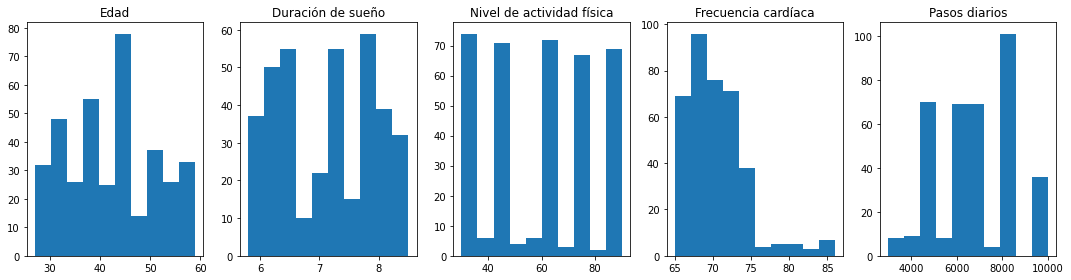

In [42]:
## Histogramas

fig, ax = plt.subplots(1, 5, figsize=(15, 4))

ax[0].hist(df['Age'])   
ax[0].set_title('Edad')
ax[1].hist(df['Sleep Duration'])  
ax[1].set_title('Duración de sueño')
ax[2].hist(df['Physical Activity Level'])
ax[2].set_title('Nivel de actividad física')
ax[3].hist(df['Heart Rate'])
ax[3].set_title('Frecuencia cardíaca')
ax[4].hist(df['Daily Steps'])
ax[4].set_title('Pasos diarios')

plt.tight_layout()

plt.show()

In [55]:
for col in columnas_numericas:
    print(f"{col}")
    print(f"  Asimetría: {df[col].skew():.4f}")
    print(f"  Curtosis: {df[col].kurt():.4f}")
    print()

Age
  Asimetría: 0.2572
  Curtosis: -0.9098

Sleep Duration
  Asimetría: 0.0376
  Curtosis: -1.2865

Physical Activity Level
  Asimetría: 0.0745
  Curtosis: -1.2661

Heart Rate
  Asimetría: 1.2248
  Curtosis: 2.2865

Daily Steps
  Asimetría: 0.1783
  Curtosis: -0.3940



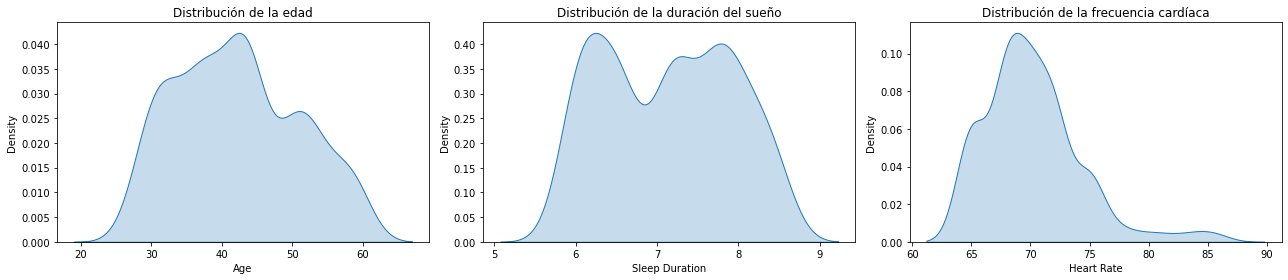

In [50]:
## Kernel Density Estimation

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.kdeplot(data=df, x="Age", fill=True, ax=axes[0])
sns.kdeplot(data=df, x="Sleep Duration", fill=True, ax=axes[1])
sns.kdeplot(data=df, x="Heart Rate", fill=True, ax=axes[2])

axes[0].set_title("Distribución de la edad")
axes[1].set_title("Distribución de la duración del sueño")
axes[2].set_title("Distribución de la frecuencia cardíaca")

plt.tight_layout()
plt.show()

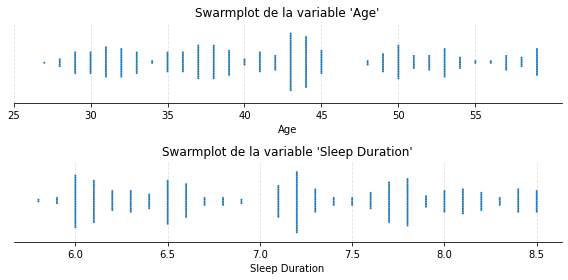

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(8, 4))

# Age
sns.swarmplot(x=df["Age"], size=2, ax=axes[0])
axes[0].set_xticks(np.arange(25, int(df["Age"].max()) + 1, 5))
axes[0].grid(axis="x", which="major", linestyle="--", alpha=0.4)
axes[0].set_yticks([])
axes[0].set_ylabel("")
axes[0].set_xlabel("Age")
axes[0].set_title("Swarmplot de la variable 'Age'")

# Sleep Duration
sns.swarmplot(x=df["Sleep Duration"], size=2, ax=axes[1])
axes[1].grid(axis="x", which="major", linestyle="--", alpha=0.4)
axes[1].set_yticks([])
axes[1].set_ylabel("")
axes[1].set_xlabel("Sleep Duration")
axes[1].set_title("Swarmplot de la variable 'Sleep Duration'")

sns.despine(left=True)

plt.tight_layout()
plt.show()

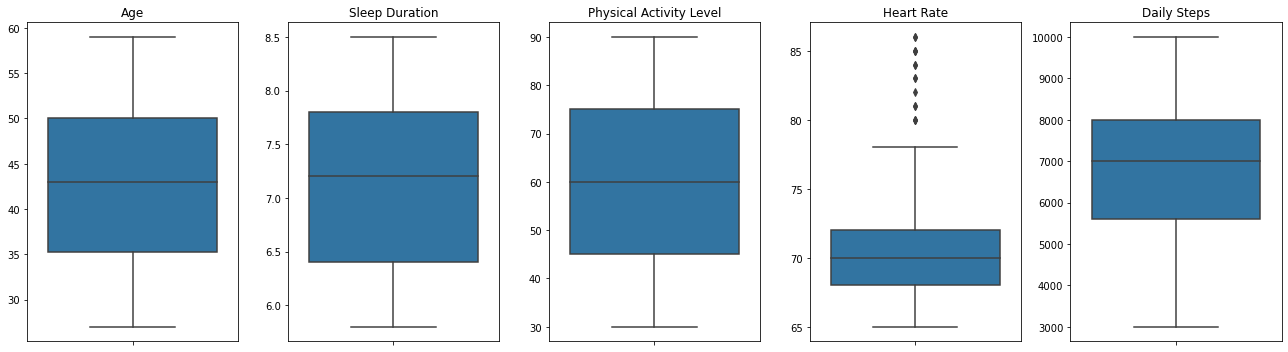

In [51]:
## Boxplots
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(columnas_numericas):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

### Variables categóricas

In [5]:
columnas_categoricas = ["Gender","Occupation","BMI Category","Sleep Disorder", "Quality of Sleep", "Stress Level"]

for col in columnas_categoricas:
    print(f"\n--- {col} ---")
    tabla = pd.DataFrame({
        "Frecuencia absoluta": df[col].value_counts(),
        "Frecuencia relativa %": (df[col].value_counts(normalize=True) * 100).round(2)
    })
    display(tabla)



--- Gender ---


,Frecuencia absoluta,Frecuencia relativa %
Male,189,50.53
Female,185,49.47



--- Occupation ---


,Frecuencia absoluta,Frecuencia relativa %
Nurse,73,19.52
Doctor,71,18.98
Engineer,63,16.84
Lawyer,47,12.57
Teacher,40,10.70
Accountant,37,9.89
Salesperson,32,8.56
Scientist,4,1.07
Software Engineer,4,1.07
Sales Representative,2,0.53



--- BMI Category ---


...

,Frecuencia absoluta,Frecuencia relativa %
None,219,58.56
Sleep Apnea,78,20.86
Insomnia,77,20.59



--- Quality of Sleep ---


,Frecuencia absoluta,Frecuencia relativa %
8,109,29.14
6,105,28.07
7,77,20.59
9,71,18.98
5,7,1.87
4,5,1.34



--- Stress Level ---


,Frecuencia absoluta,Frecuencia relativa %
3,71,18.98
4,70,18.72
8,70,18.72
5,67,17.91
7,50,13.37
6,46,12.30


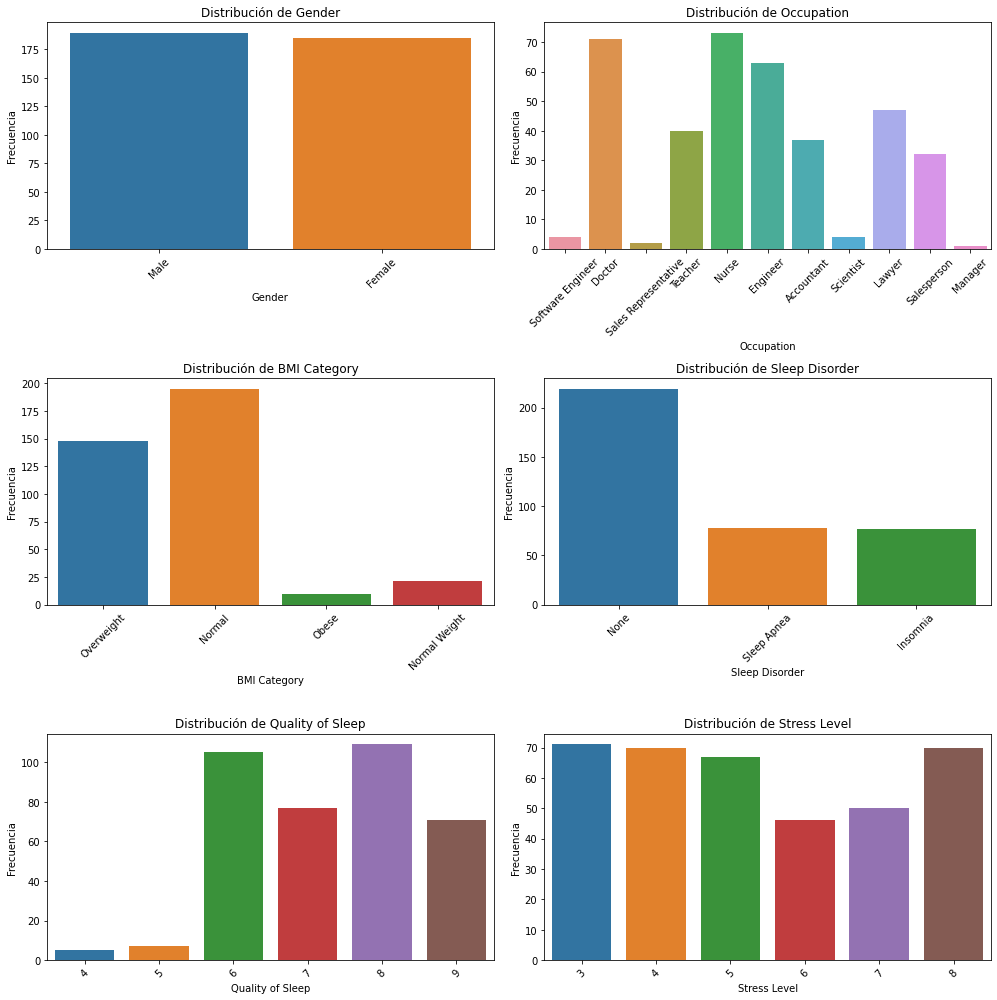

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

axes = axes.flatten()

for i, col in enumerate(columnas_categoricas):
    sns.countplot(data=df, x=col, ax=axes[i])

    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

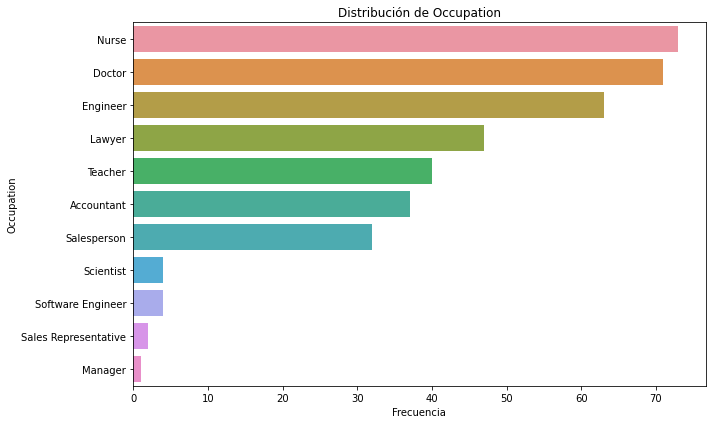

In [8]:
## gráfico horizontal aparte para ver la variable Occupation
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Occupation",
    order=df["Occupation"].value_counts().index
)

plt.title("Distribución de Occupation")
plt.xlabel("Frecuencia")
plt.ylabel("Occupation")

plt.tight_layout()
plt.show()

### Relación entre variables

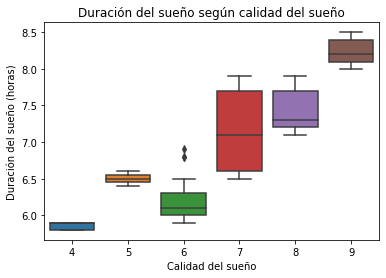

In [6]:
## Relación entre duración del sueño (numérica) y calidad del sueño (categórica)
sns.boxplot(
    data=df,
    x="Quality of Sleep",
    y="Sleep Duration"
)

plt.title("Duración del sueño según calidad del sueño")
plt.xlabel("Calidad del sueño")
plt.ylabel("Duración del sueño (horas)")
plt.show()

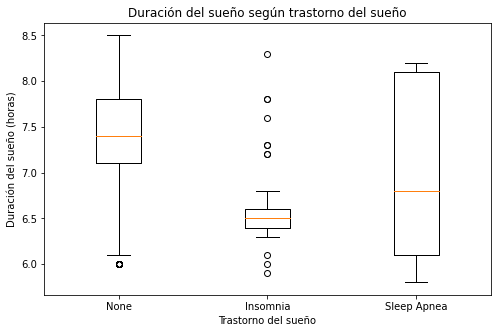

In [9]:
## relación entre duración del sueño (numérica) y trastorno del sueño (categórica)
orden_trastornos = ["None", "Insomnia", "Sleep Apnea"]

datos_boxplot = [
    df.loc[df["Sleep Disorder"] == categoria, "Sleep Duration"]
    for categoria in orden_trastornos
]

plt.figure(figsize=(8, 5))
plt.boxplot(datos_boxplot, labels=orden_trastornos)
plt.title("Duración del sueño según trastorno del sueño")
plt.xlabel("Trastorno del sueño")
plt.ylabel("Duración del sueño (horas)")
plt.show()

In [10]:
df.groupby("Sleep Disorder")["Sleep Duration"].agg(
    ["count", "mean", "median", "std"]
).round(2)


,count,mean,median,std
Sleep Disorder,,,,
Insomnia,77,6.59,6.5,0.39
None,219,7.36,7.4,0.73
Sleep Apnea,78,7.03,6.8,0.97


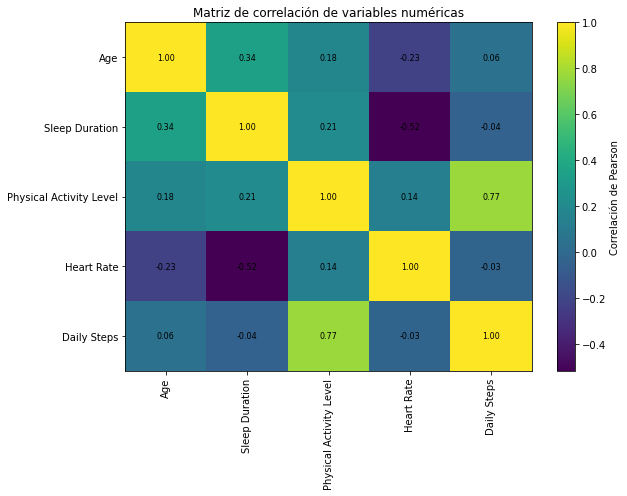

In [14]:
corr = df[columnas_numericas].corr(method="pearson")

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlación de Pearson")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

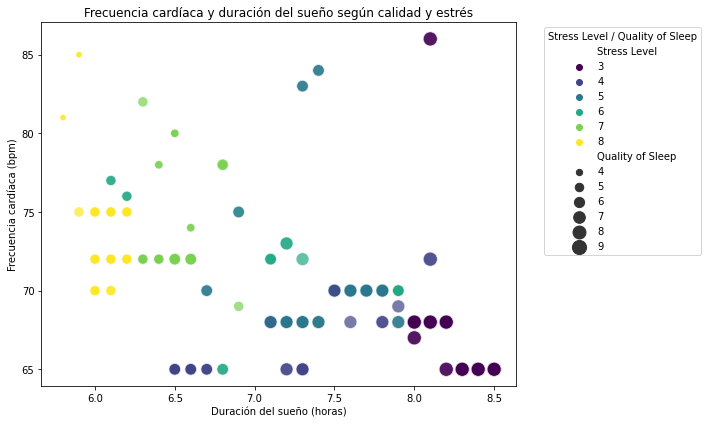

In [17]:
## Relación entre duración del sueño (numérica), frecuencia cardíaca (numérica), nivel de estrés y calidad del sueño (categóricas)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sleep Duration",
    y="Heart Rate",
    hue="Stress Level",
    size="Quality of Sleep",
    sizes=(40, 200),
    alpha=0.7,
    palette="viridis"
)

plt.title("Frecuencia cardíaca y duración del sueño según calidad y estrés")
plt.xlabel("Duración del sueño (horas)")
plt.ylabel("Frecuencia cardíaca (bpm)")

plt.legend(
    title="Stress Level / Quality of Sleep",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

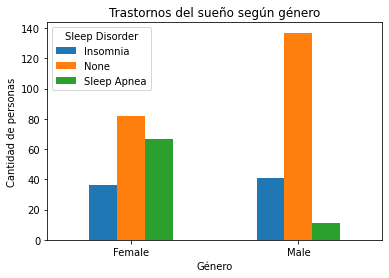

In [15]:
## Relación entre género (categórica) y trastorno del sueño (categórica)

tabla_contingencia = pd.crosstab(df["Gender"], df["Sleep Disorder"])
tabla_contingencia.plot(kind="bar")
plt.title("Trastornos del sueño según género")
plt.xlabel("Género")
plt.ylabel("Cantidad de personas")
plt.xticks(rotation=0)
plt.legend(title="Sleep Disorder")
plt.show()


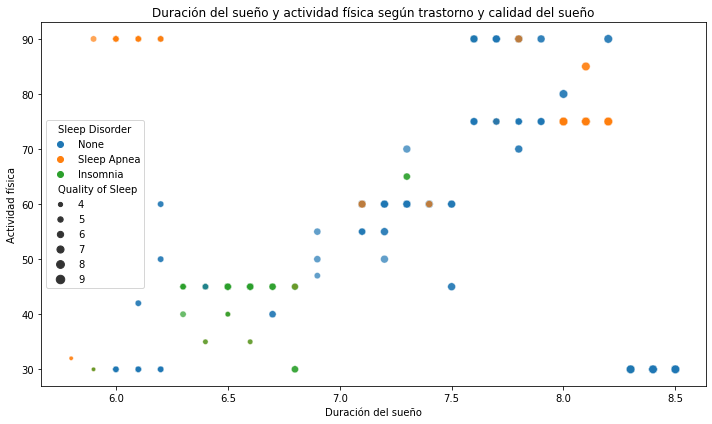

In [16]:
## Relación entre duración del sueño (numérica), actividad física (numérica), trastorno y calidad del sueño (categóricas)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sleep Duration",
    y="Physical Activity Level",
    hue="Sleep Disorder",
    size="Quality of Sleep",
    alpha=0.7
)

plt.title("Duración del sueño y actividad física según trastorno y calidad del sueño")
plt.xlabel("Duración del sueño")
plt.ylabel("Actividad física")

plt.tight_layout()
plt.show()

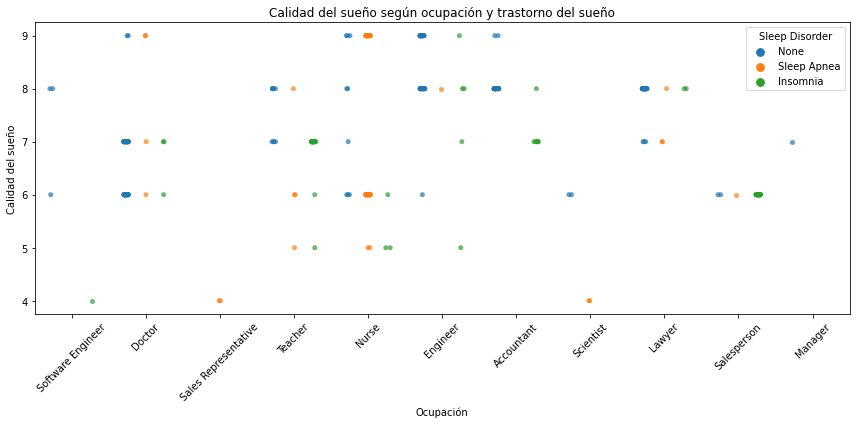

In [18]:
plt.figure(figsize=(12, 6))

sns.stripplot(
    data=df,
    x="Occupation",
    y="Quality of Sleep",
    hue="Sleep Disorder",
    dodge=True,
    jitter=True,
    alpha=0.7
)

plt.title("Calidad del sueño según ocupación y trastorno del sueño")
plt.xlabel("Ocupación")
plt.ylabel("Calidad del sueño")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()